# ChatGPT Customer Reviews Sentiment Analysis

## Project Objective

This project aims to analyze customer reviews of ChatGPT to understand user satisfaction levels and identify common positive and negative feedback patterns.

The analysis includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Sentiment Analysis
- Subjectivity Analysis
- Keyword Extraction
- Data Visualization

### Business Question

What are users saying about ChatGPT, and what improvements can be identified through customer feedback?

# Import Required Libraries

The following libraries are used for:

- Data manipulation (Pandas)
- Data visualization (Matplotlib, Seaborn)
- Sentiment analysis (TextBlob)
- Keyword extraction and word clouds

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

The dataset contains customer reviews of ChatGPT along with ratings and review dates.

We first load the dataset and inspect its structure.

In [1]:
import pandas as pd

df = pd.read_csv("chatgpt_reviews.csv")
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


# Dataset Overview

Understanding the dataset structure helps identify:

- Number of records
- Column names
- Data types
- Missing values

In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


,0
Review Id,0
Review,6
Ratings,0
Review Date,0


# Data Cleaning

To ensure accurate analysis:

1. Standardize column names
2. Handle missing values
3. Convert ratings to numeric format
4. Convert review dates into datetime format

In [3]:
df.columns = ['review_id','review','rating','review_date']

df['review'] = df['review'].fillna('')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['review_date'] = pd.to_datetime(df['review_date'])

# Feature Engineering

Additional features are created to enrich the analysis.

Created Features:

- Review Length
- Word Count
- Review Month

In [4]:
df['review_length'] = df['review'].str.len()

df['word_count'] = df['review'].apply(
    lambda x: len(str(x).split())
)

df['month'] = df['review_date'].dt.to_period('M')

In [5]:
!pip install textblob

# Sentiment Analysis

Sentiment analysis helps determine whether a review is:

- Positive
- Negative
- Neutral

We use TextBlob to calculate:

1. Polarity
2. Subjectivity

In [7]:
from textblob import TextBlob

df['polarity'] = df['review'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df['subjectivity'] = df['review'].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

# Sentiment Classification

Reviews are categorized based on polarity scores.

Rules:

- Positive : Polarity > 0
- Negative : Polarity < 0
- Neutral : Polarity = 0

In [8]:
def sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(sentiment_label)

# Exploratory Data Analysis

## Rating Distribution

This visualization shows how users rated ChatGPT.

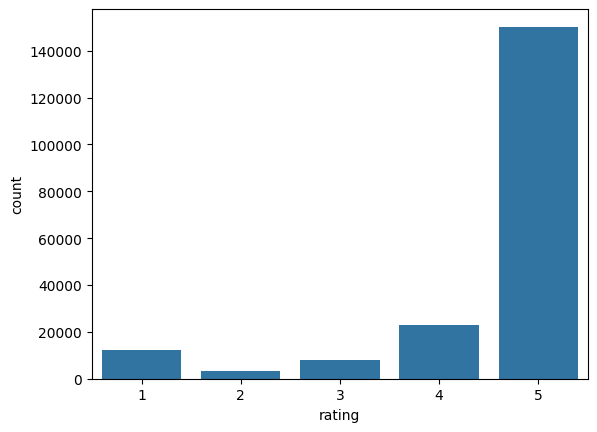

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='rating', data=df)
plt.show()

### Observation

Most users provided ratings between 4 and 5 stars, indicating generally positive customer satisfaction.

# Sentiment Distribution

This chart shows the number of positive, neutral, and negative reviews.

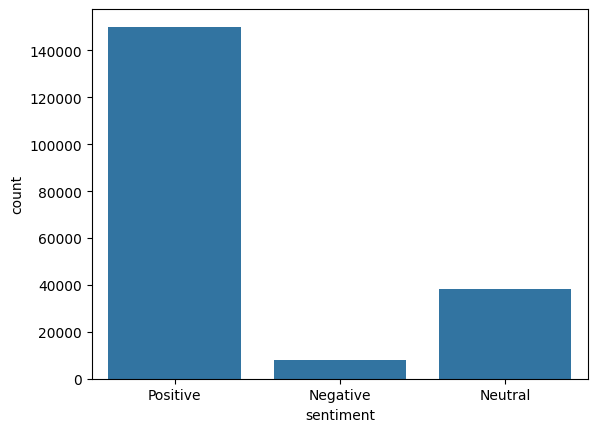

In [10]:
sns.countplot(x='sentiment', data=df)
plt.show()

### Observation

Positive reviews dominate the dataset, suggesting strong overall user satisfaction.

# Subjectivity Distribution

Subjectivity measures how opinion-based reviews are.

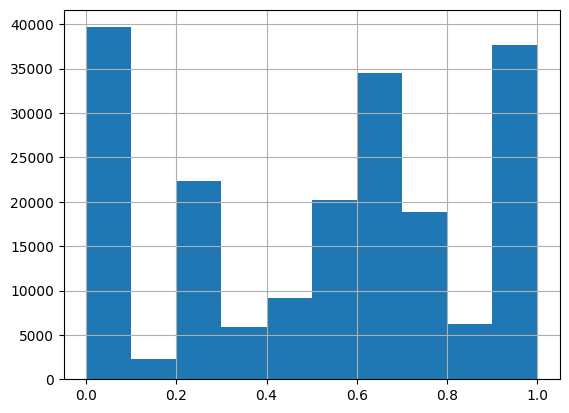

In [11]:
df['subjectivity'].hist()
plt.show()

# Polarity Distribution

Polarity values range from:

-1 = Very Negative

0 = Neutral

+1 = Very Positive

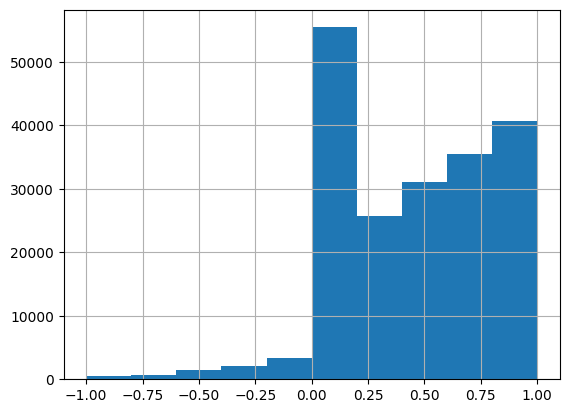

In [12]:
df['polarity'].hist()
plt.show()

# Rating vs Sentiment Analysis

This analysis helps verify whether user ratings align with sentiment scores.

In [13]:
pd.crosstab(
    df['rating'],
    df['sentiment']
)

sentiment,Negative,Neutral,Positive
rating,,,
1,3591,4684,3808
2,709,979,1687
3,831,1957,5369
4,872,3993,18032
5,2152,26837,121226


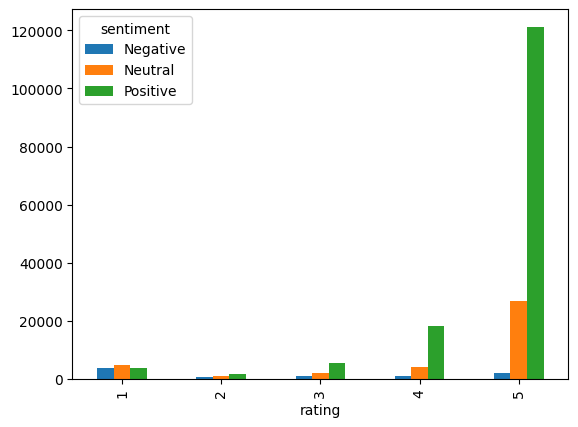

In [14]:
pd.crosstab(
    df['rating'],
    df['sentiment']
).plot(kind='bar')
plt.show()

# Positive Review Analysis

The goal is to identify words frequently used in positive reviews.

In [15]:
positive_reviews = df[
    df['sentiment']=='Positive'
]

In [16]:
from collections import Counter
import re

text = ' '.join(
    positive_reviews['review'].astype(str)
)

words = re.findall(r'\w+', text.lower())

Counter(words).most_common(20)

[('it', 58127),
 ('app', 44956),
 ('good', 39186),
 ('i', 38276),
 ('the', 36908),
 ('very', 35307),
 ('and', 34669),
 ('is', 32786),
 ('to', 30513),
 ('this', 25467),
 ('a', 23298),
 ('for', 22767),
 ('s', 18988),
 ('best', 18363),
 ('in', 13788),
 ('nice', 13760),
 ('of', 13013),
 ('you', 12551),
 ('great', 11926),
 ('my', 11098)]

In [ ]:
!pip install wordcloud

### Observation

Common positive keywords indicate users appreciate ChatGPT's helpfulness, accuracy, and productivity benefits.

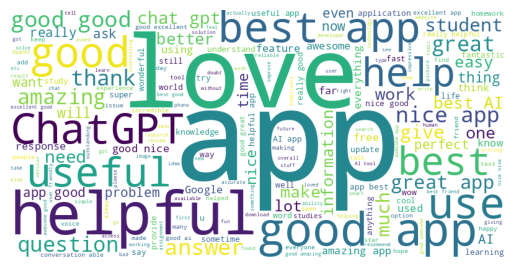

In [17]:
from wordcloud import WordCloud

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

# Negative Review Analysis

The objective is to identify common complaints among users.

In [18]:
df[df['sentiment']=='Negative']

,review_id,review,rating,review_date,review_length,word_count,month,polarity,subjectivity,sentiment
10,17769ae4-51f6-439c-af12-f59d242e1f6b,I am not very happy with this because chatgpt ...,3,2024-08-23 19:09:14,332,61,2024-08,-0.172527,0.495604,Negative
119,13fb28dc-df81-4ef0-8842-edd3625fa600,not good,1,2024-08-23 16:41:21,8,2,2024-08,-0.350000,0.600000,Negative
134,0e0adf90-8e2d-402a-8cc1-c82275b958a8,Too expensive,1,2024-08-23 16:20:49,13,2,2024-08,-0.500000,0.700000,Negative
176,f86c8ac6-325e-4f3c-83a6-eed16c8e845e,"Correct answer Accuracy 10 %,always provide wr...",1,2024-08-23 15:46:16,60,8,2024-08,-0.500000,0.900000,Negative
222,edc628fe-24ad-4bb5-8a16-113ec8fec341,"I get a ""something went wrong"" error so I can'...",1,2024-08-23 15:15:03,55,12,2024-08,-0.500000,0.900000,Negative
...,...,...,...,...,...,...,...,...,...,...
196341,02d669c0-9046-4b84-a27d-dbd385464269,As expected,5,2023-08-08 01:57:23,11,2,2023-08,-0.100000,0.400000,Negative
196617,d982d12c-49fc-48e3-b01b-9aa90bb3b9a9,random sjsj,5,2024-01-01 15:32:55,11,2,2024-01,-0.500000,0.500000,Negative
196665,2085e4bf-b5ec-4015-91ea-e825e8272464,Not sure,5,2024-04-24 17:22:58,8,2,2024-04,-0.250000,0.888889,Negative
196672,1e90cfd6-91d8-43da-a54e-45f985c70ea9,hands down,5,2024-03-17 10:03:42,10,2,2024-03,-0.155556,0.288889,Negative


In [19]:
df.to_csv(
    "chatgpt_reviews_sentiment.csv",
    index=False
)

# Key Insights

## Positive Findings

- Majority of reviews are positive.
- Users frequently praise ChatGPT's usefulness.
- Coding assistance is a commonly appreciated feature.

## Negative Findings

- Some users report incorrect responses.
- Reliability concerns appear in negative reviews.

## Recommendations

1. Improve response consistency.
2. Reduce factual inaccuracies.
3. Continue enhancing coding assistance.
4. Focus on reliability improvements.

## Conclusion

The analysis indicates that ChatGPT enjoys strong overall user satisfaction, with positive reviews significantly outweighing negative feedback. Users value its productivity and problem-solving capabilities, while accuracy and reliability remain opportunities for future enhancement.